
## Import e setup


In [1]:
import sys
import os
import ast
import copy
import random
import yaml
import numpy as np
import pandas as pd
import torch

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

from src.datasets.gqa_graph_dataset import GQAGraphDataset
from src.models.gnn import GINEEmbeddingNet
from src.evaluation.retrieval import (
    compute_graph_embeddings,
    evaluate_retrieval,
    print_metrics,
    plot_graph_retrieval,
    plot_tsne,
)

from src.utils.perturb import perturb_graph_objects, perturb_dataframe

p:\Anaconda\envs\torch_new\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:


config_path = os.path.join(BASE_DIR, "experiments", "configs", "gine_config.yaml")
with open(config_path) as f:
    cfg = yaml.safe_load(f)

device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt_path  = os.path.join(BASE_DIR, cfg["training"]["checkpoint"])
checkpoint = torch.load(ckpt_path, map_location=device)

node_vocab = checkpoint["node_vocab"]
rel_vocab  = checkpoint["rel_vocab"]

print(f"Checkpoint caricato da: {ckpt_path}")
print(f"node_vocab size: {len(node_vocab)} | rel_vocab size: {len(rel_vocab)}")


Checkpoint caricato da: p:\Uni\mujoco\dl26-projects\experiments/checkpoints/gnn20.pth
node_vocab size: 1637 | rel_vocab size: 308


In [4]:

df_train = pd.read_csv(os.path.join(BASE_DIR, cfg["data"]["train_csv"]))
df_val   = pd.read_csv(os.path.join(BASE_DIR, cfg["data"]["val_csv"]))

all_labels = df_train["labels"].unique()
label2idx  = {l: i for i, l in enumerate(all_labels)}
idx2label  = {i: l for l, i in label2idx.items()}

df_train["labels"] = df_train["labels"].map(label2idx)
df_val["labels"]   = df_val["labels"].map(label2idx)

drop_prob    = cfg["evaluation"]["drop_prob"]
perturbed_df = perturb_dataframe(df_val, drop_prob=drop_prob)

val_dataset = GQAGraphDataset(
    df=perturbed_df,
    label_col="labels",
    node_vocab=node_vocab,
    rel_vocab=rel_vocab,
    label2idx=label2idx,
    idx2label=idx2label,
    use_bbox=cfg["model"]["use_bbox"],
)


In [5]:

gine_model = GINEEmbeddingNet(
    num_node_types=len(node_vocab) + 1,
    edge_vocab_size=len(rel_vocab),
    emb_dim=cfg["model"]["emb_dim"],
    hidden_dim=cfg["model"]["hidden_dim"],
    num_layers=cfg["model"]["num_layers"],
    dropout=cfg["model"]["dropout"],
    use_bbox=cfg["model"]["use_bbox"],
    node_emb_dim=cfg["model"]["node_emb_dim"],
).to(device)

gine_model.load_state_dict(checkpoint["model_state_dict"])
gine_model.eval()


GINEEmbeddingNet(
  (node_emb): Embedding(1638, 64, padding_idx=0)
  (node_encoder): Sequential(
    (0): Linear(in_features=68, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
  )
  (edge_encoder): Embedding(308, 256)
  (convs): ModuleList(
    (0-3): 4 x GINEConv(nn=Sequential(
      (0): Linear(in_features=256, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=256, bias=True)
    ))
  )
  (norms): ModuleList(
    (0-3): 4 x LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (projector): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
  )
)

In [6]:

embeddings, labels = compute_graph_embeddings(
    model=gine_model,
    dataset=val_dataset,
    device=device,
    batch_size=cfg["dataloader"]["batch_size"],
    num_workers=cfg["dataloader"]["num_workers"],
    normalize=True,
)

print("Embeddings shape:", embeddings.shape)
print("Labels shape:    ", labels.shape)

results, indices, scores = evaluate_retrieval(
    embeddings,
    labels,
    ks=(1, 5, 10),
)

print_metrics(results)


Embeddings shape: torch.Size([3208, 128])
Labels shape:     torch.Size([3208])

========== Retrieval Metrics ==========

acc@1               : 0.4613
precision_macro     : 0.4518
recall_macro        : 0.4351
recall@1            : 0.4613
recall@5            : 0.7519
recall@10           : 0.8466
precision@1         : 0.4613
precision@5         : 0.4486
precision@10        : 0.4503
mrr                 : 0.5866
map                 : 0.5369



Query indices: [1250 2366  158  503  593]


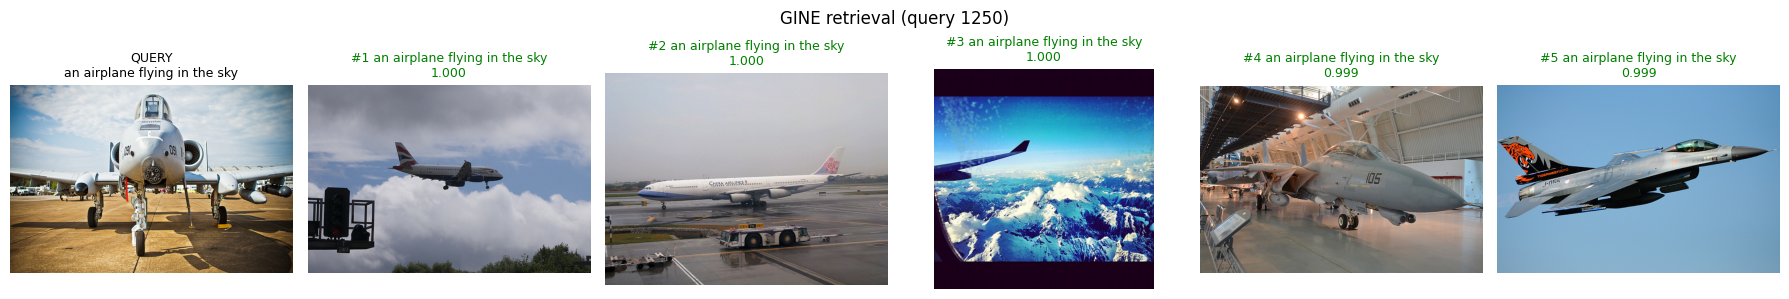


Query 1250: an airplane flying in the sky
#1 idx=1875 score=1.000 an airplane flying in the sky [OK]
#2 idx=2228 score=1.000 an airplane flying in the sky [OK]
#3 idx=539 score=1.000 an airplane flying in the sky [OK]
#4 idx=1265 score=0.999 an airplane flying in the sky [OK]
#5 idx=2926 score=0.999 an airplane flying in the sky [OK]


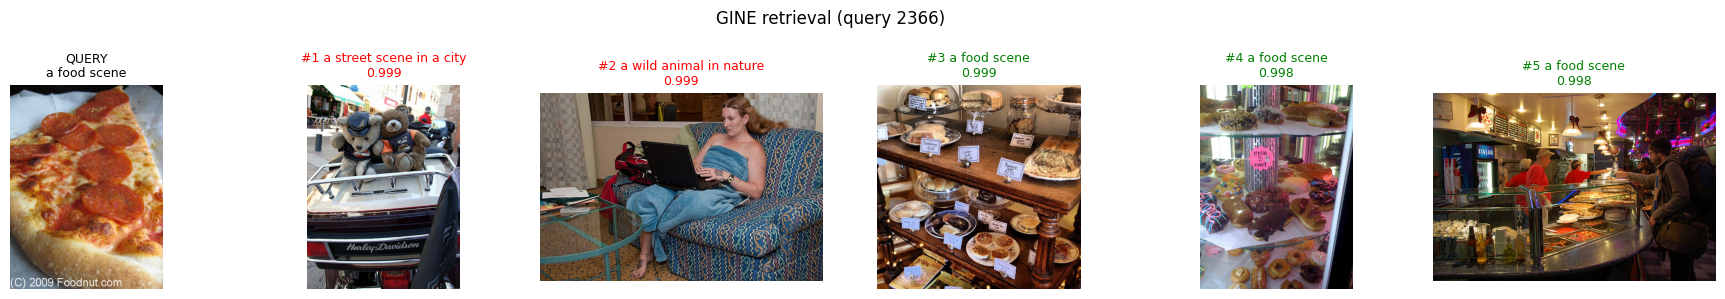


Query 2366: a food scene
#1 idx=2247 score=0.999 a street scene in a city [MISS]
#2 idx=1150 score=0.999 a wild animal in nature [MISS]
#3 idx=557 score=0.999 a food scene [OK]
#4 idx=729 score=0.998 a food scene [OK]
#5 idx=2188 score=0.998 a food scene [OK]


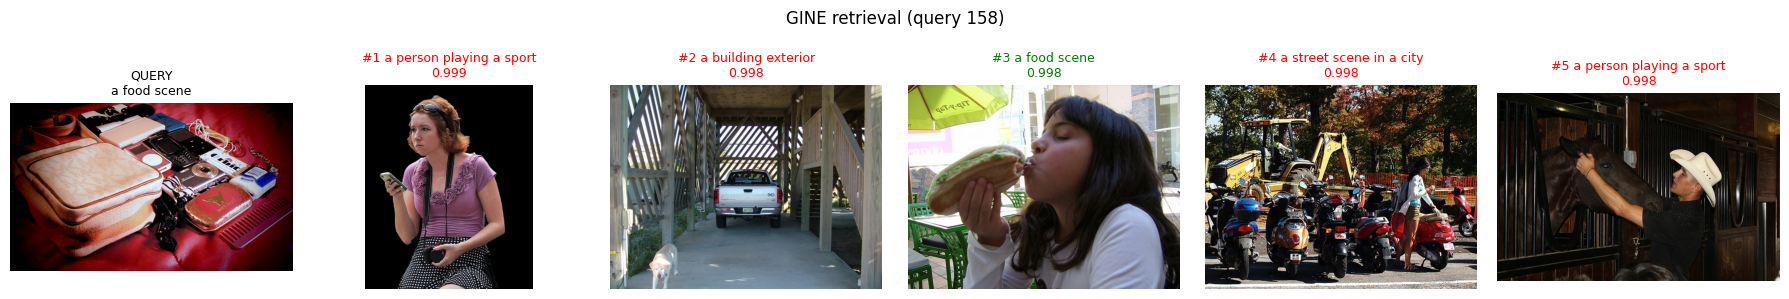


Query 158: a food scene
#1 idx=2146 score=0.999 a person playing a sport [MISS]
#2 idx=1915 score=0.998 a building exterior [MISS]
#3 idx=2607 score=0.998 a food scene [OK]
#4 idx=1387 score=0.998 a street scene in a city [MISS]
#5 idx=2066 score=0.998 a person playing a sport [MISS]


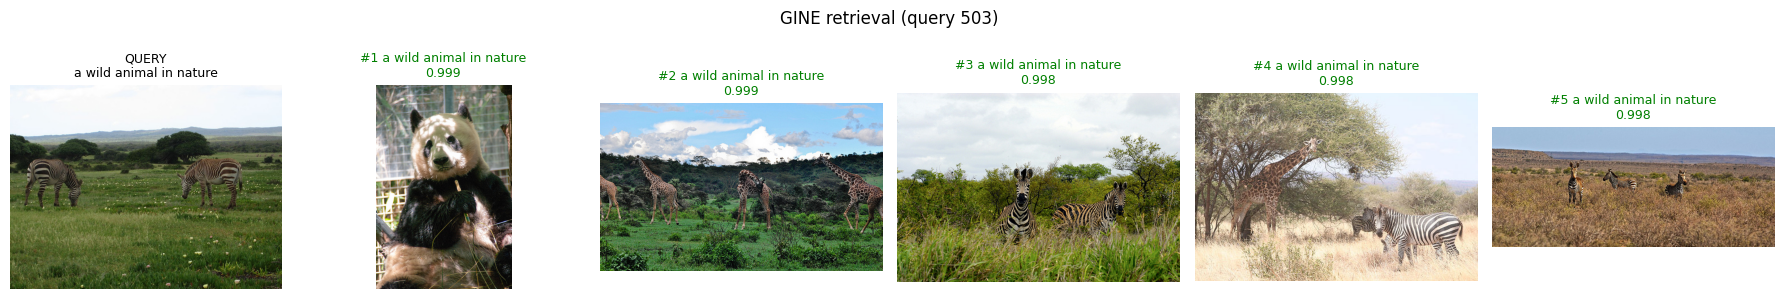


Query 503: a wild animal in nature
#1 idx=737 score=0.999 a wild animal in nature [OK]
#2 idx=2958 score=0.999 a wild animal in nature [OK]
#3 idx=2074 score=0.998 a wild animal in nature [OK]
#4 idx=2629 score=0.998 a wild animal in nature [OK]
#5 idx=2113 score=0.998 a wild animal in nature [OK]


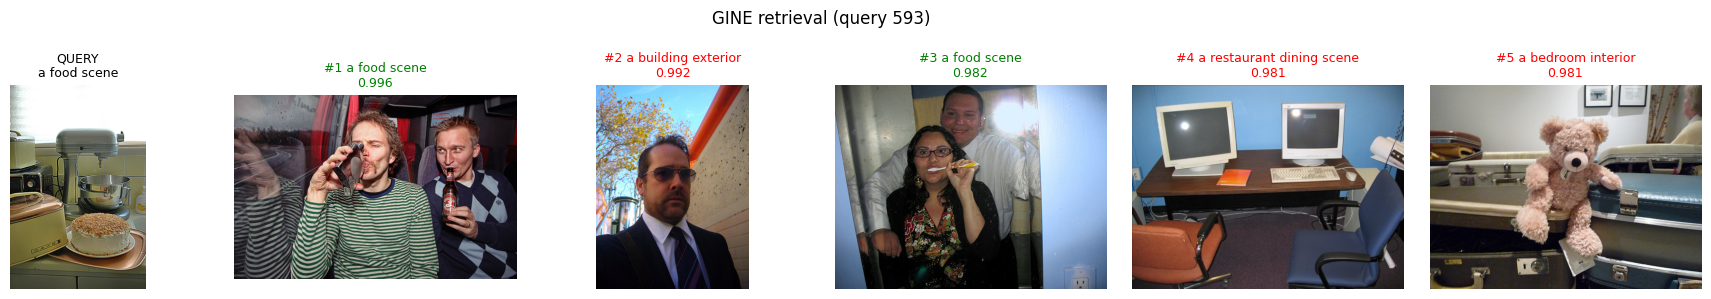


Query 593: a food scene
#1 idx=1354 score=0.996 a food scene [OK]
#2 idx=3070 score=0.992 a building exterior [MISS]
#3 idx=909 score=0.982 a food scene [OK]
#4 idx=2335 score=0.981 a restaurant dining scene [MISS]
#5 idx=1081 score=0.981 a bedroom interior [MISS]


In [7]:

IMAGE_DIR = os.path.join(BASE_DIR, "data", "images")

np.random.seed(40)
query_indices = np.random.choice(len(labels), size=5, replace=False)
print("Query indices:", query_indices)

for query_idx in query_indices:
    plot_graph_retrieval(
        df=val_dataset,
        image_dir=IMAGE_DIR,
        labels=labels,
        indices=indices,
        scores=scores,
        query_idx=query_idx,
        idx2label=val_dataset.idx2label,
        topk=5,
        title=f"GINE retrieval (query {query_idx})",
    )

    q_label = labels[query_idx].item()
    print(f"\nQuery {query_idx}: {val_dataset.idx2label.get(q_label, q_label)}")

    for rank, (idx, score) in enumerate(
        zip(indices[query_idx][1:6], scores[query_idx][1:6]),
        start=1
    ):
        lbl  = int(labels[idx])
        mark = "OK" if lbl == q_label else "MISS"
        print(
            f"#{rank} idx={idx} score={score:.3f} "
            f"{val_dataset.idx2label.get(lbl, lbl)} [{mark}]"
        )


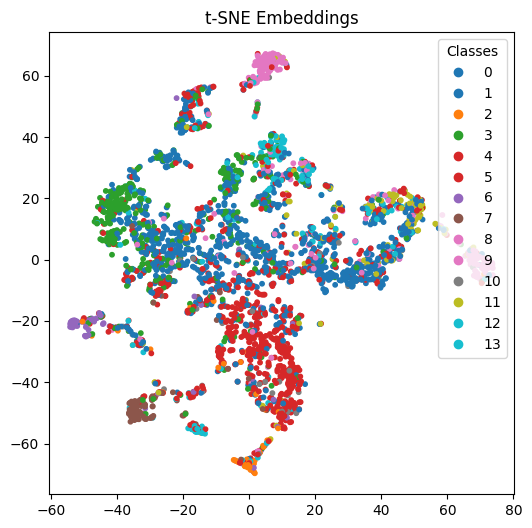

In [8]:

plot_tsne(
    embeddings=embeddings,
    labels=labels,
)